<a href="https://colab.research.google.com/github/hemanthgm914856/Handwritten-Digit-Generator-using-DCGAN/blob/main/Handwritten_Digit_Generator_using_DCGAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================
# Handwritten Digit Generator using DCGAN
# Dataset: MNIST
# Platform: Google Colab
# ============================================

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# Load MNIST dataset
(x_train, _), (_, _) = mnist.load_data()

print("Original dataset shape:", x_train.shape)

# Convert images from (28, 28) to (28, 28, 1)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

# Normalize pixel values from [0, 255] to [-1, 1]
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5

print("Processed dataset shape:", x_train.shape)
print("Pixel range:", x_train.min(), "to", x_train.max())

Original dataset shape: (60000, 28, 28)
Processed dataset shape: (60000, 28, 28, 1)
Pixel range: -1.0 to 1.0


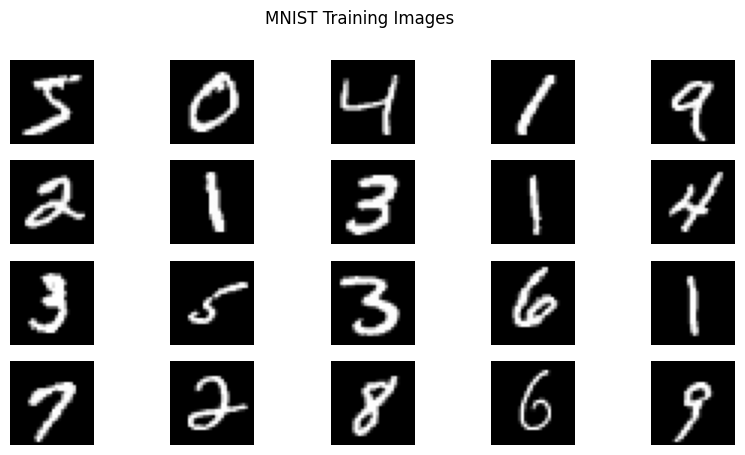

In [5]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

plt.suptitle("MNIST Training Images")
plt.show()

In [6]:
BATCH_SIZE = 256
BUFFER_SIZE = 60000

train_dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE)
)

print("Dataset ready!")

Dataset ready!


In [7]:
LATENT_DIM = 100

def build_generator():

    model = tf.keras.Sequential(name="Generator")

    # Random noise: 100 values
    model.add(layers.Dense(7 * 7 * 256, use_bias=False,
                           input_shape=(LATENT_DIM,)))

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Convert to 7x7x256
    model.add(layers.Reshape((7, 7, 256)))

    # 7x7 -> 14x14
    model.add(
        layers.Conv2DTranspose(
            128,
            kernel_size=5,
            strides=1,
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # 14x14 -> 28x28
    model.add(
        layers.Conv2DTranspose(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False
        )
    )

    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Final image: 28x28x1
    model.add(
        layers.Conv2DTranspose(
            1,
            kernel_size=5,
            strides=2,
            padding="same",
            use_bias=False,
            activation="tanh"
        )
    )

    return model


generator = build_generator()

generator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

In [8]:
noise = tf.random.normal([1, LATENT_DIM])

generated_image = generator(noise, training=False)

print("Generated image shape:", generated_image.shape)

Generated image shape: (1, 28, 28, 1)


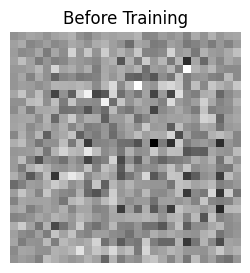

In [9]:
plt.figure(figsize=(3, 3))

plt.imshow(
    generated_image[0, :, :, 0],
    cmap="gray"
)

plt.axis("off")
plt.title("Before Training")

plt.show()

In [10]:
def build_discriminator():

    model = tf.keras.Sequential(name="Discriminator")

    # Input: 28x28x1
    model.add(
        layers.Conv2D(
            64,
            kernel_size=5,
            strides=2,
            padding="same",
            input_shape=(28, 28, 1)
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(
        layers.Conv2D(
            128,
            kernel_size=5,
            strides=2,
            padding="same"
        )
    )

    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())

    # Output: real/fake score
    model.add(layers.Dense(1))

    return model


discriminator = build_discriminator()

discriminator.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
decision = discriminator(generated_image)

print("Discriminator output:", decision.numpy())

Discriminator output: [[-0.00074491]]


In [12]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(
    from_logits=True
)

In [13]:
def generator_loss(fake_output):

    return cross_entropy(
        tf.ones_like(fake_output),
        fake_output
    )

In [14]:
def discriminator_loss(real_output, fake_output):

    real_loss = cross_entropy(
        tf.ones_like(real_output),
        real_output
    )

    fake_loss = cross_entropy(
        tf.zeros_like(fake_output),
        fake_output
    )

    total_loss = real_loss + fake_loss

    return total_loss

In [15]:
generator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator_optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

In [16]:
EPOCHS = 50

NUM_EXAMPLES_TO_GENERATE = 16

# Fixed noise for visualizing progress
seed = tf.random.normal(
    [NUM_EXAMPLES_TO_GENERATE, LATENT_DIM]
)

generator_losses = []
discriminator_losses = []

In [17]:
@tf.function
def train_step(images):

    noise = tf.random.normal(
        [BATCH_SIZE, LATENT_DIM]
    )

    with tf.GradientTape() as gen_tape, \
         tf.GradientTape() as disc_tape:

        # Generate fake images
        generated_images = generator(
            noise,
            training=True
        )

        # Discriminator predictions
        real_output = discriminator(
            images,
            training=True
        )

        fake_output = discriminator(
            generated_images,
            training=True
        )

        # Calculate losses
        gen_loss = generator_loss(
            fake_output
        )

        disc_loss = discriminator_loss(
            real_output,
            fake_output
        )

    # Calculate gradients
    gradients_of_generator = gen_tape.gradient(
        gen_loss,
        generator.trainable_variables
    )

    gradients_of_discriminator = disc_tape.gradient(
        disc_loss,
        discriminator.trainable_variables
    )

    # Update weights
    generator_optimizer.apply_gradients(
        zip(
            gradients_of_generator,
            generator.trainable_variables
        )
    )

    discriminator_optimizer.apply_gradients(
        zip(
            gradients_of_discriminator,
            discriminator.trainable_variables
        )
    )

    return gen_loss, disc_loss

In [18]:
def generate_and_save_images(model, epoch, test_input):

    predictions = model(
        test_input,
        training=False
    )

    fig = plt.figure(figsize=(8, 8))

    for i in range(predictions.shape[0]):

        plt.subplot(4, 4, i + 1)

        plt.imshow(
            predictions[i, :, :, 0],
            cmap="gray"
        )

        plt.axis("off")

    plt.suptitle(
        f"Generated Digits - Epoch {epoch}"
    )

    plt.tight_layout()

    filename = f"/content/generated_epoch_{epoch}.png"

    plt.savefig(filename)

    plt.show()

    print("Saved:", filename)

In [19]:
def train(dataset, epochs):

    for epoch in range(1, epochs + 1):

        print(f"\nEpoch {epoch}/{epochs}")

        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:

            gen_loss, disc_loss = train_step(
                image_batch
            )

            epoch_gen_loss.append(
                float(gen_loss)
            )

            epoch_disc_loss.append(
                float(disc_loss)
            )

        avg_gen_loss = np.mean(epoch_gen_loss)
        avg_disc_loss = np.mean(epoch_disc_loss)

        generator_losses.append(avg_gen_loss)
        discriminator_losses.append(avg_disc_loss)

        print(
            f"Generator Loss: {avg_gen_loss:.4f} | "
            f"Discriminator Loss: {avg_disc_loss:.4f}"
        )

        # Generate images every 5 epochs
        if epoch == 1 or epoch % 5 == 0:
            generate_and_save_images(
                generator,
                epoch,
                seed
            )


Epoch 1/50
Generator Loss: 0.6683 | Discriminator Loss: 1.3248


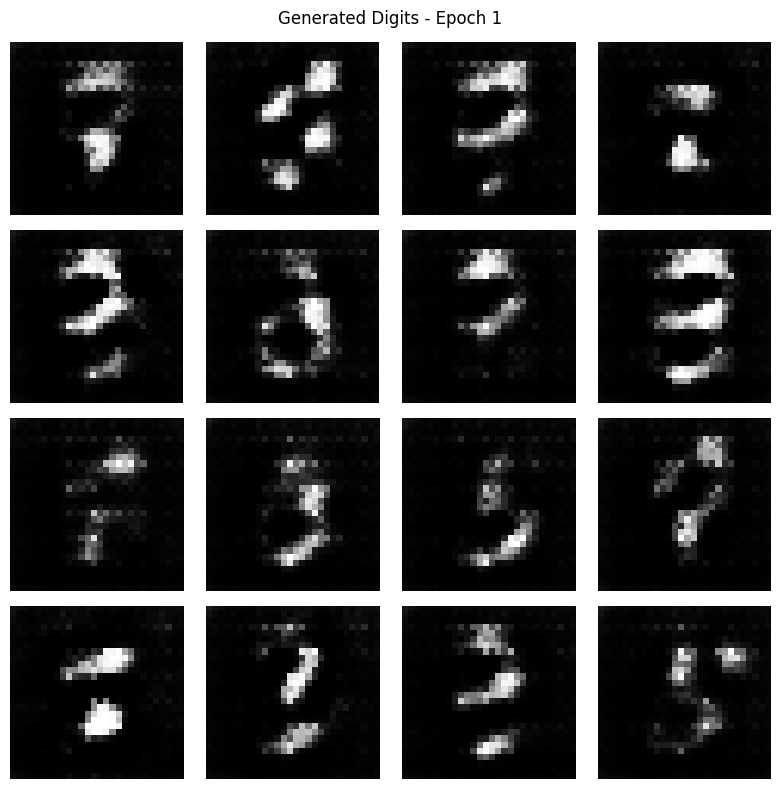

Saved: /content/generated_epoch_1.png

Epoch 2/50
Generator Loss: 0.7226 | Discriminator Loss: 1.3581

Epoch 3/50
Generator Loss: 0.7372 | Discriminator Loss: 1.3477

Epoch 4/50
Generator Loss: 0.7592 | Discriminator Loss: 1.3264

Epoch 5/50
Generator Loss: 0.7913 | Discriminator Loss: 1.3013


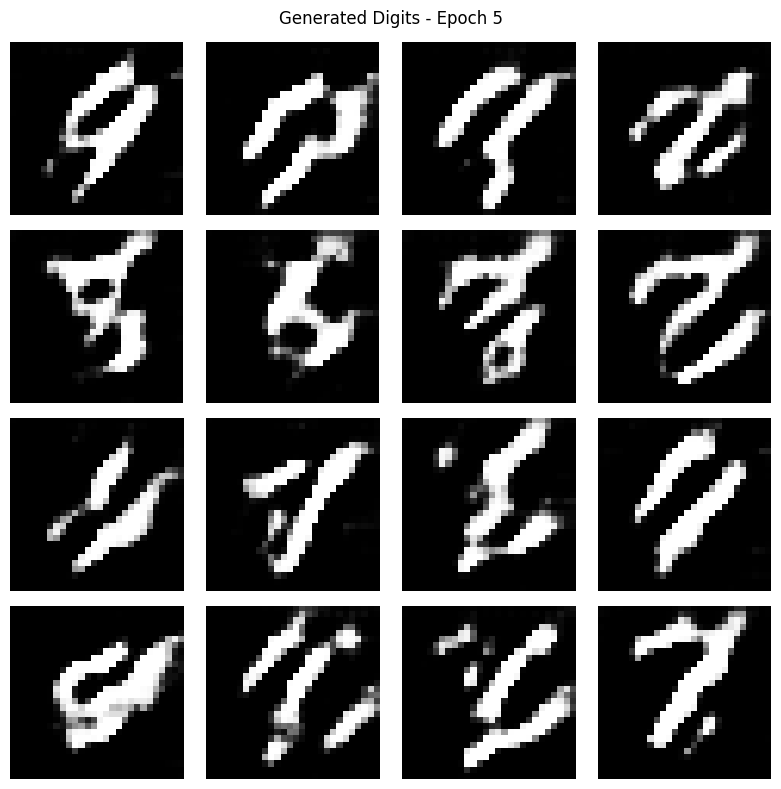

Saved: /content/generated_epoch_5.png

Epoch 6/50
Generator Loss: 0.8239 | Discriminator Loss: 1.2737

Epoch 7/50
Generator Loss: 0.8420 | Discriminator Loss: 1.2524

Epoch 8/50
Generator Loss: 0.8334 | Discriminator Loss: 1.2805

Epoch 9/50
Generator Loss: 0.7964 | Discriminator Loss: 1.3111

Epoch 10/50
Generator Loss: 0.7874 | Discriminator Loss: 1.3191


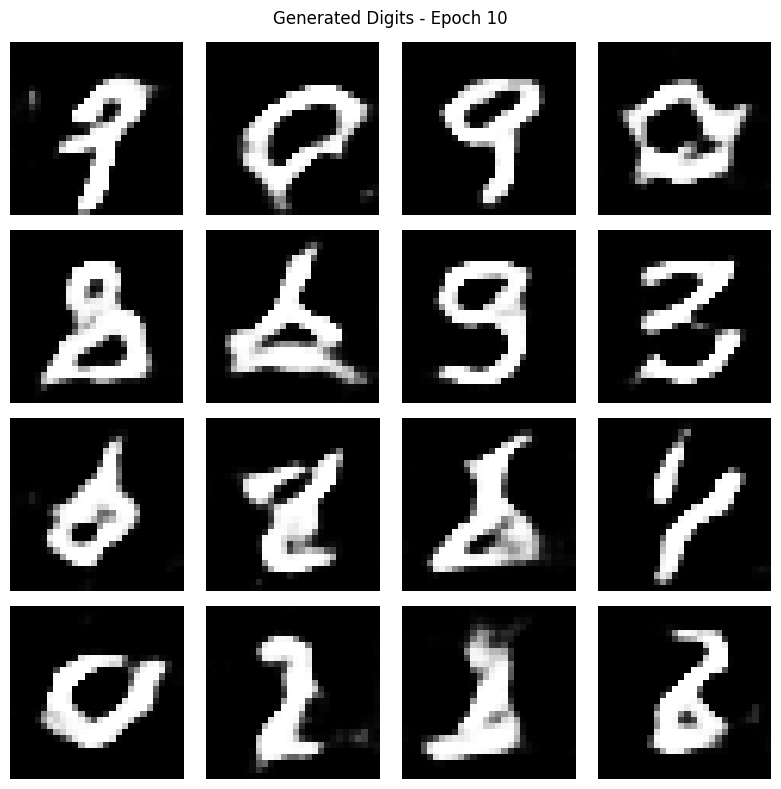

Saved: /content/generated_epoch_10.png

Epoch 11/50
Generator Loss: 0.7932 | Discriminator Loss: 1.3153

Epoch 12/50
Generator Loss: 0.7730 | Discriminator Loss: 1.3239

Epoch 13/50
Generator Loss: 0.7916 | Discriminator Loss: 1.3163

Epoch 14/50
Generator Loss: 0.7862 | Discriminator Loss: 1.3181

Epoch 15/50
Generator Loss: 0.7790 | Discriminator Loss: 1.3230


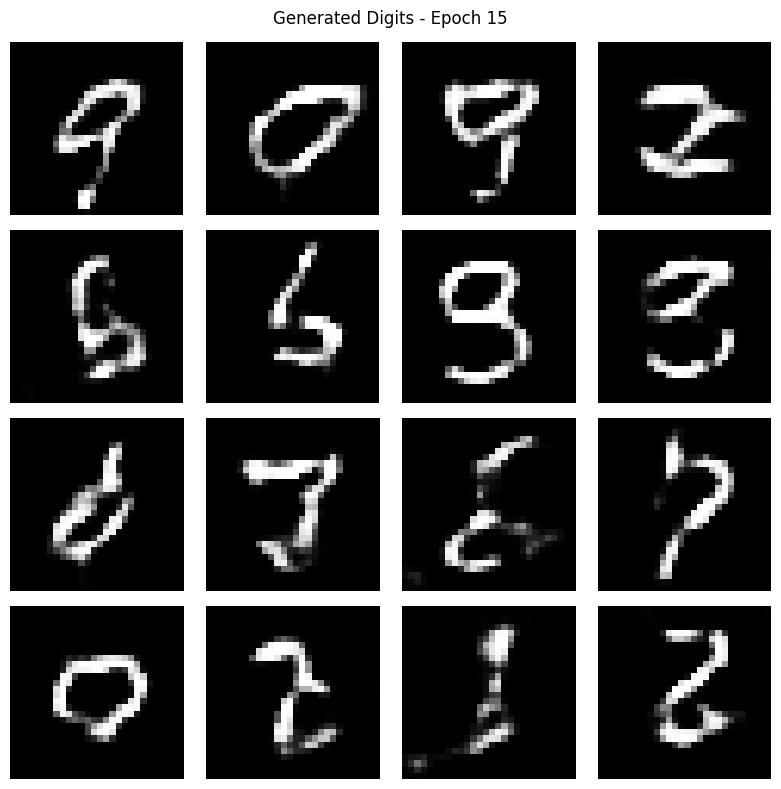

Saved: /content/generated_epoch_15.png

Epoch 16/50
Generator Loss: 0.7895 | Discriminator Loss: 1.3144

Epoch 17/50
Generator Loss: 0.7914 | Discriminator Loss: 1.3157

Epoch 18/50
Generator Loss: 0.7826 | Discriminator Loss: 1.3181

Epoch 19/50
Generator Loss: 0.7891 | Discriminator Loss: 1.3141

Epoch 20/50
Generator Loss: 0.8037 | Discriminator Loss: 1.3080


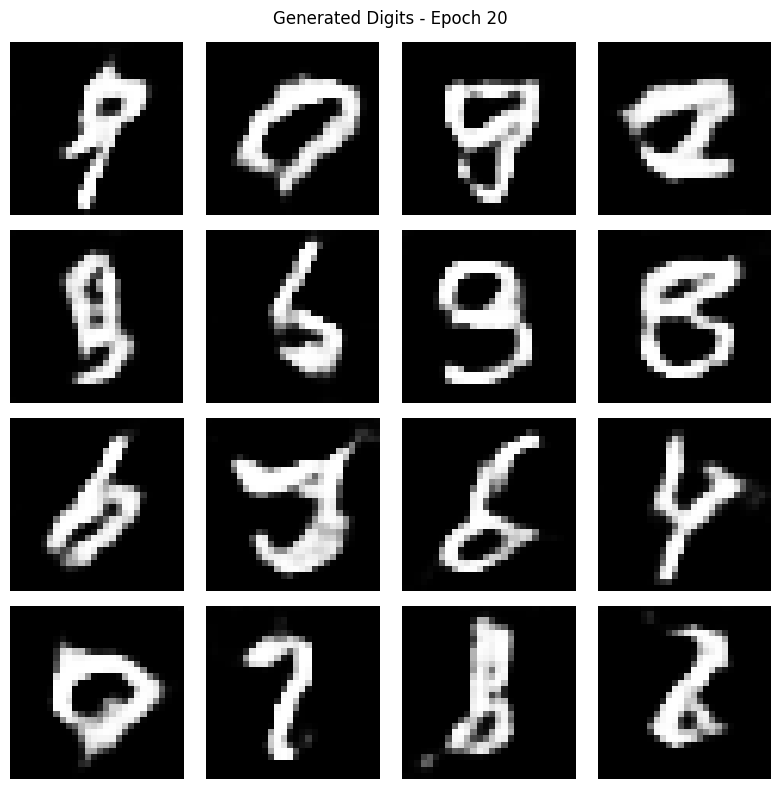

Saved: /content/generated_epoch_20.png

Epoch 21/50
Generator Loss: 0.7975 | Discriminator Loss: 1.3100

Epoch 22/50
Generator Loss: 0.8065 | Discriminator Loss: 1.3044

Epoch 23/50
Generator Loss: 0.7993 | Discriminator Loss: 1.3068

Epoch 24/50
Generator Loss: 0.7904 | Discriminator Loss: 1.3120

Epoch 25/50
Generator Loss: 0.8216 | Discriminator Loss: 1.2991


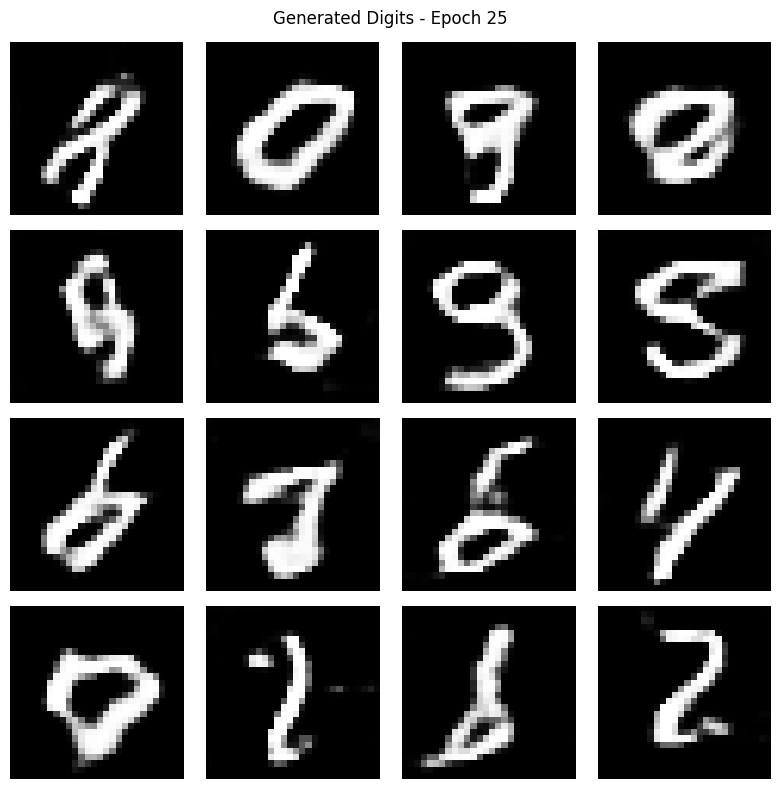

Saved: /content/generated_epoch_25.png

Epoch 26/50
Generator Loss: 0.8117 | Discriminator Loss: 1.3015

Epoch 27/50
Generator Loss: 0.7986 | Discriminator Loss: 1.3064

Epoch 28/50
Generator Loss: 0.8210 | Discriminator Loss: 1.3009

Epoch 29/50
Generator Loss: 0.8122 | Discriminator Loss: 1.2988

Epoch 30/50
Generator Loss: 0.8143 | Discriminator Loss: 1.3017


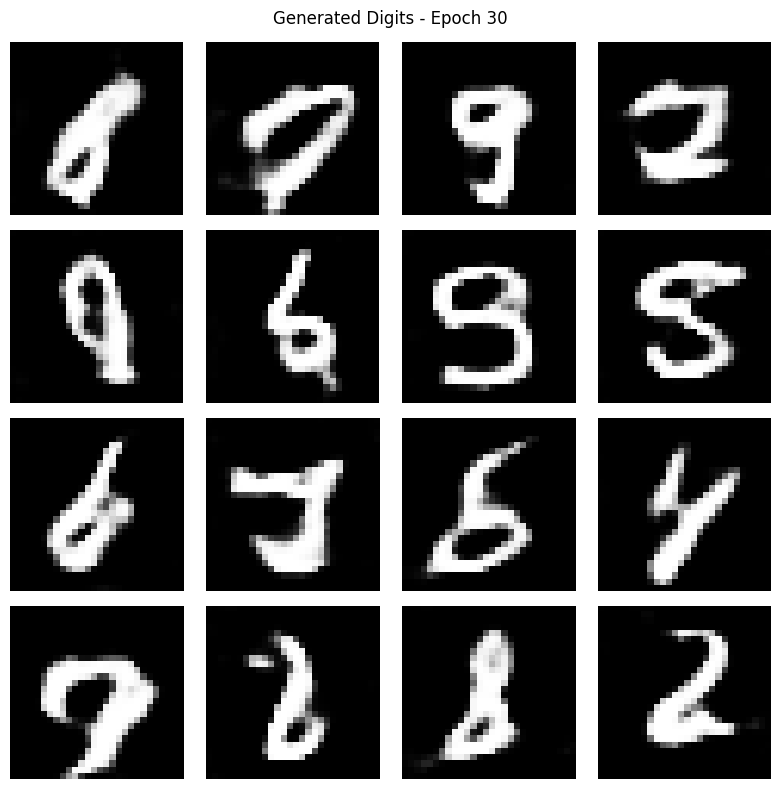

Saved: /content/generated_epoch_30.png

Epoch 31/50
Generator Loss: 0.8133 | Discriminator Loss: 1.2992

Epoch 32/50
Generator Loss: 0.8045 | Discriminator Loss: 1.3040

Epoch 33/50
Generator Loss: 0.8266 | Discriminator Loss: 1.3021

Epoch 34/50
Generator Loss: 0.8150 | Discriminator Loss: 1.2985

Epoch 35/50
Generator Loss: 0.7995 | Discriminator Loss: 1.3071


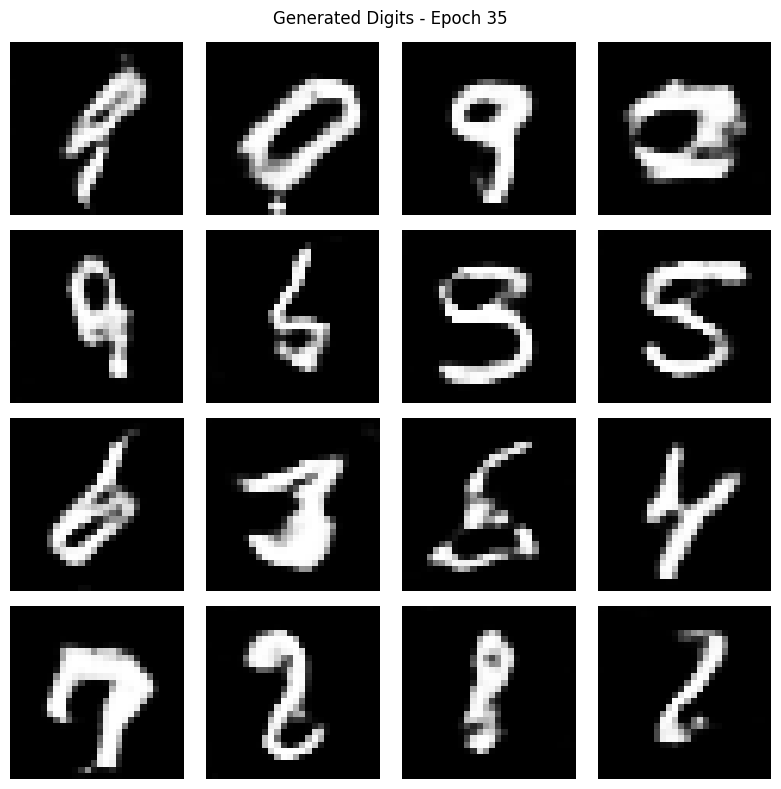

Saved: /content/generated_epoch_35.png

Epoch 36/50
Generator Loss: 0.8126 | Discriminator Loss: 1.3056

Epoch 37/50
Generator Loss: 0.8267 | Discriminator Loss: 1.3011

Epoch 38/50
Generator Loss: 0.8248 | Discriminator Loss: 1.2957

Epoch 39/50
Generator Loss: 0.8102 | Discriminator Loss: 1.3003

Epoch 40/50
Generator Loss: 0.8126 | Discriminator Loss: 1.3038


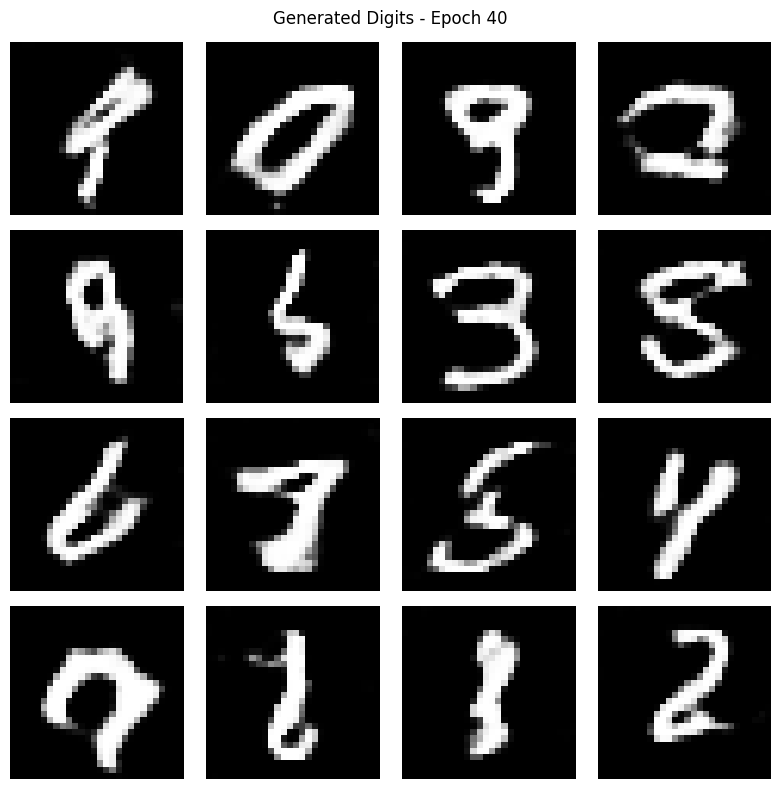

Saved: /content/generated_epoch_40.png

Epoch 41/50
Generator Loss: 0.8255 | Discriminator Loss: 1.3020

Epoch 42/50
Generator Loss: 0.8201 | Discriminator Loss: 1.3005

Epoch 43/50
Generator Loss: 0.8118 | Discriminator Loss: 1.3032

Epoch 44/50
Generator Loss: 0.8036 | Discriminator Loss: 1.3084

Epoch 45/50
Generator Loss: 0.8338 | Discriminator Loss: 1.3012


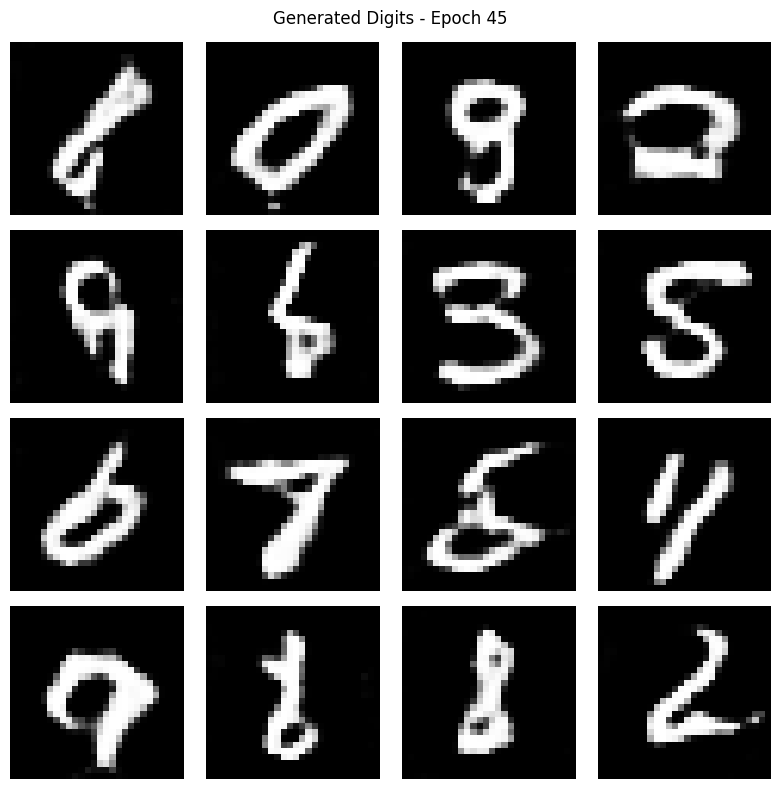

Saved: /content/generated_epoch_45.png

Epoch 46/50
Generator Loss: 0.8123 | Discriminator Loss: 1.3020

Epoch 47/50
Generator Loss: 0.8007 | Discriminator Loss: 1.3113

Epoch 48/50
Generator Loss: 0.8104 | Discriminator Loss: 1.3086

Epoch 49/50
Generator Loss: 0.8233 | Discriminator Loss: 1.3041

Epoch 50/50
Generator Loss: 0.8152 | Discriminator Loss: 1.3041


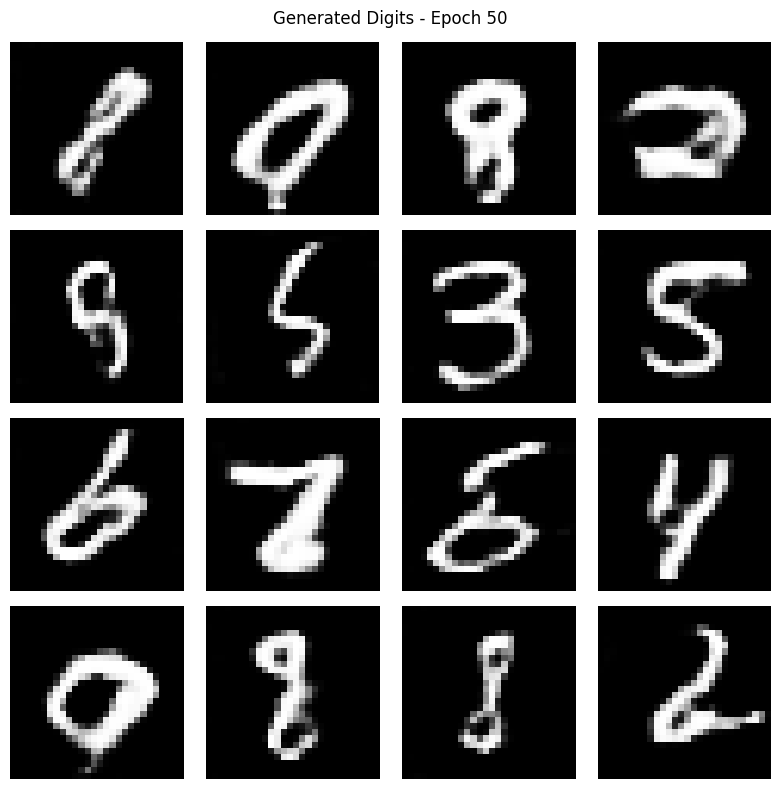

Saved: /content/generated_epoch_50.png


In [20]:
train(train_dataset, EPOCHS)

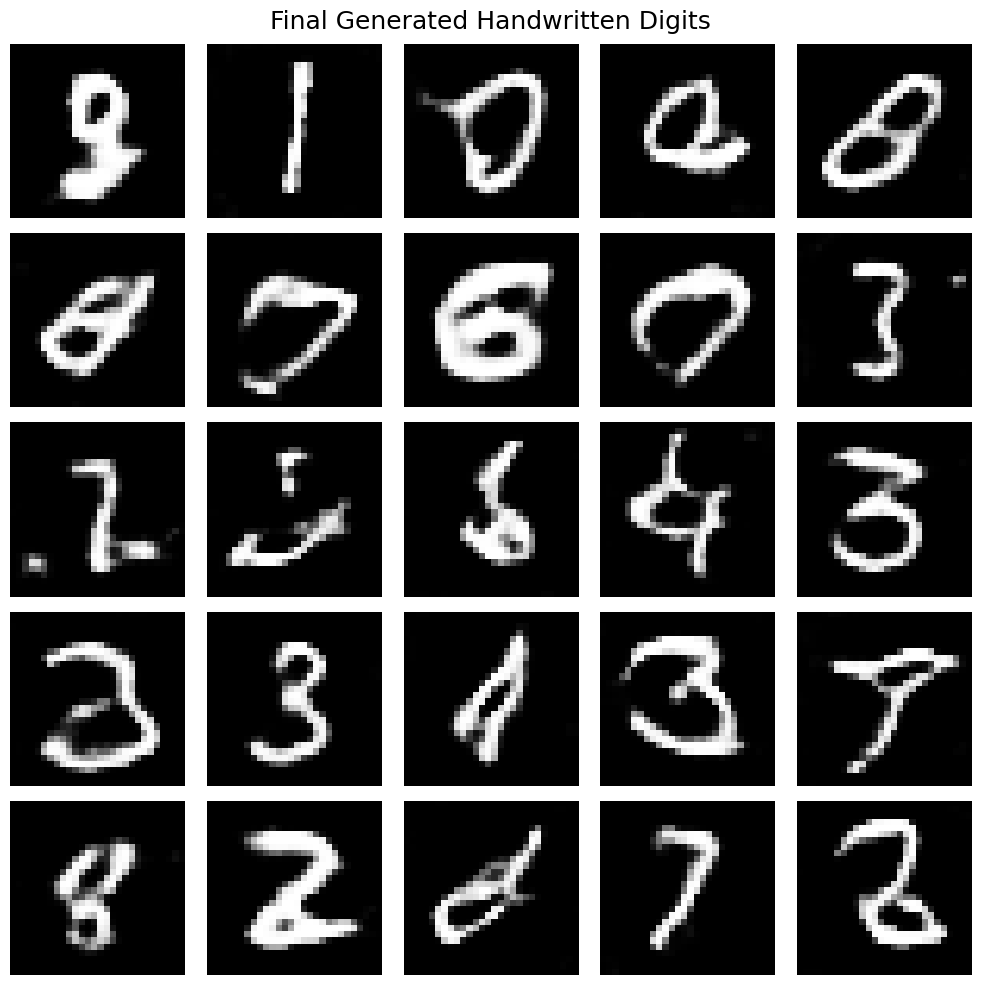

In [21]:
noise = tf.random.normal(
    [25, LATENT_DIM]
)

generated_images = generator(
    noise,
    training=False
)

plt.figure(figsize=(10, 10))

for i in range(25):

    plt.subplot(5, 5, i + 1)

    plt.imshow(
        generated_images[i, :, :, 0],
        cmap="gray"
    )

    plt.axis("off")

plt.suptitle(
    "Final Generated Handwritten Digits",
    fontsize=18
)

plt.tight_layout()
plt.show()

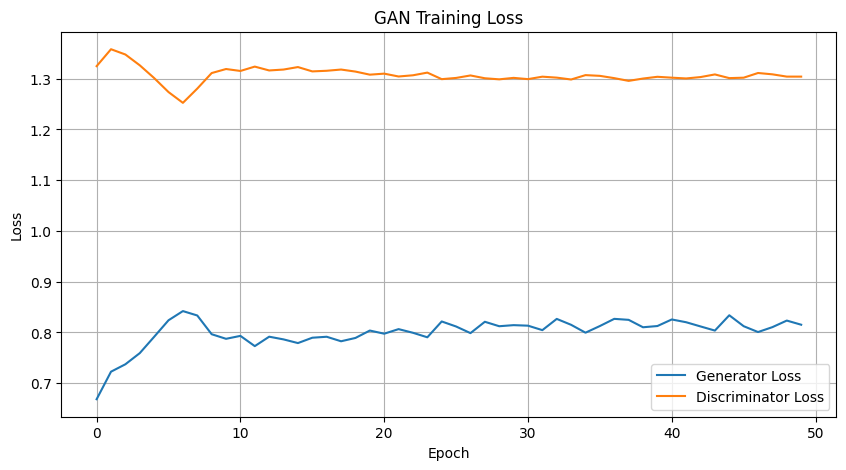

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    generator_losses,
    label="Generator Loss"
)

plt.plot(
    discriminator_losses,
    label="Discriminator Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("GAN Training Loss")

plt.legend()
plt.grid(True)

plt.show()

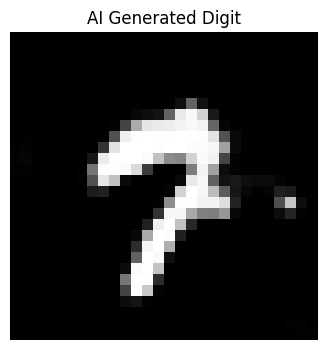

In [23]:
noise = tf.random.normal(
    [1, LATENT_DIM]
)

image = generator(
    noise,
    training=False
)

plt.figure(figsize=(4, 4))

plt.imshow(
    image[0, :, :, 0],
    cmap="gray"
)

plt.axis("off")
plt.title("AI Generated Digit")

plt.show()

In [24]:
generator.save(
    "/content/mnist_digit_generator.keras"
)

print("Generator saved successfully!")

Generator saved successfully!


In [25]:
from google.colab import files

files.download(
    "/content/mnist_digit_generator.keras"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>